# Image Feature Extraction using CNNs

This notebook extracts visual features from product images using pretrained CNN models.

**Approach:**
- Use pretrained ResNet50 (trained on ImageNet, MIT license)
- Extract dense feature vectors from images
- Save feature embeddings for model training

**Model Choice:** ResNet50 is lightweight (~25M parameters), well-documented, and MIT licensed.

In [3]:
import os
from pathlib import Path
import pandas as pd
from utils import download_images

train_file = 'train.csv'
test_file = 'test.csv'

# alright lets get the data
print("loading training data...")
train_df = pd.read_csv(train_file)
print(f"train samples: {len(train_df)}")

print("loading test data...")
test_df = pd.read_csv(test_file)
print(f"test samples: {len(test_df)}")

print("\nwhat are the columns?")
print(train_df.columns)


# download training images
train_img_folder = 'train_images'
Path(train_img_folder).mkdir(exist_ok=True, parents=True) # make sure folder exists

print(f"\nDownloading {len(train_df)} train images to: {train_img_folder}")

# get the links, drop any missing ones
train_links = train_df['image_link'].dropna().tolist()

# this util should handle the download
download_images(train_links, str(train_img_folder))

print("...done with train images")


# now do the same for test images
test_img_folder = 'test_images'
os.makedirs(test_img_folder, exist_ok=True) # another way to do it

print(f"\nDownloading {len(test_df)} test images to: {test_img_folder}")

test_links = test_df['image_link'].dropna().tolist()

download_images(test_links, str(test_img_folder))

print("...done with test images!")

loading training data...
train samples: 75000
loading test data...
test samples: 75000

what are the columns?
Index(['sample_id', 'catalog_content', 'image_link', 'price'], dtype='object')



 52%|█████▏    | 38906/75000 [00:19<00:07, 4864.76it/s]

HTTP Error 404: Not Found


100%|██████████| 75000/75000 [00:26<00:00, 2822.69it/s]


...done with train images



 56%|█████▌    | 41978/75000 [00:05<00:05, 5979.43it/s]

HTTP Error 404: Not Found


100%|██████████| 75000/75000 [00:11<00:00, 6297.46it/s]


...done with test images!


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import pickle

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# check for gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

if str(device) == 'cuda':
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    # print(f"CUDA Version: {torch.version.cuda}")

Running on: cpu


## Load Pretrained ResNet50 Model

ResNet50 is a well-established CNN architecture that provides excellent feature representations.
We'll use it as a feature extractor by removing the final classification layer.

In [5]:
print("Loading pretrained ResNet50 model...")
# this thing is trained on imagenet, should be a good base

# use the newer `weights` param, not pretrained=True
resnet_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)


# default resnet gives 2048 features. that's a bit much for this.
# going to chop off the head and add a new one to get 512 features instead.
# should be way faster and use less memory.
class ResnetFeatureExtractor(nn.Module):
    def __init__(self, original_model, output_dim=512):
        super(ResnetFeatureExtractor, self).__init__()
        # get everything except the final classification layer
        self.features = nn.Sequential(*list(original_model.children())[:-1])

        # add a pooling layer and a linear layer to reduce dimensions
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(2048, output_dim) # from 2048 -> 512

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1) # flatten it out
        x = self.fc(x)
        return x

# create the actual feature extractor
feature_extractor = ResnetFeatureExtractor(resnet_model, output_dim=512)

# move to gpu if we have one
feature_extractor.to(device)
feature_extractor.eval() # set to eval mode, we're not training this part

print("\nModel ready!")
print(f"Outputting 512 features instead of 2048.")
# total_params = sum(p.numel() for p in feature_extractor.parameters())
# print(f"Total parameters: {total_params:,}")

Loading pretrained ResNet50 model...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 121MB/s]



Model ready!
Outputting 512 features instead of 2048.


## Define Image Preprocessing Pipeline

Standard ImageNet preprocessing to match the pretrained model's training.

In [6]:
# Image preprocessing pipeline
# Needs to match the standard ResNet/ImageNet setup
image_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224), # crop from the center
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # imagenet mean
        std=[0.229, 0.224, 0.225]   # imagenet std
    )
])

print("Image transforms defined.")
# print(image_transforms)

Image transforms defined.


## Feature Extraction Function

Function to extract features from a single image file.

In [7]:
def get_features_for_image(image_path, feature_dim=512):
    """
    Takes an image path and runs it through the model to get a feature vector.
    Returns a vector of zeros if the image is broken or can't be found.
    """
    try:
        # need to convert to RGB, handles grayscale images too
        img = Image.open(image_path).convert('RGB')

        # run the transforms
        img_tensor = image_transforms(img).unsqueeze(0)  # add batch dimension
        img_tensor = img_tensor.to(device)

        # no need to track gradients for this part
        with torch.no_grad():
            features = feature_extractor(img_tensor)

        # get it back to cpu and convert to numpy array
        features_np = features.squeeze().cpu().numpy()

        return features_np

    except FileNotFoundError:
        # print(f"couldnt find {image_path}") # this gets spammy
        return np.zeros(feature_dim, dtype=np.float32)

    except (OSError, IOError):
        # for corrupted images
        # print(f"bad image {image_path}")
        return np.zeros(feature_dim, dtype=np.float32)

    except Exception as e:
        # catch anything else
        print(f"An unexpected error occurred with {image_path}: {e}")
        return np.zeros(feature_dim, dtype=np.float32)

# --- Quick test on one image ---
print("\nTesting the feature extraction on a sample...")
train_img_files = list(Path('train_images').glob('*.jpg'))

# make sure we actually have images to test
if train_img_files:
    a_sample_image = train_img_files[0]
    print(f"Using image: {a_sample_image.name}")

    test_features = get_features_for_image(a_sample_image)
    print(f"Output feature shape: {test_features.shape}")
    print(f"Feature min/max: [{test_features.min():.3f}, {test_features.max():.3f}]")

else:
    print("No sample images found in 'train_images' to test.")


Testing the feature extraction on a sample...
Using image: 81N7kLa6svL.jpg
Output feature shape: (512,)
Feature min/max: [-1.155, 1.025]


## Load Dataset Mappings

Load the sample_id to image filename mappings created earlier.

In [8]:
# setup paths
FEATURES_DIR = 'features'
TRAIN_IMG_DIR = 'train_images'
TEST_IMG_DIR = 'test_images'

# Load the csv files again
print("Loading dataset info...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# The image_link is a full URL, I just want the filename part
# like `image_123.jpg`
def extract_filename(link):
    if pd.notna(link):
        return Path(link).name
    else:
        return None

train_df['image_filename'] = train_df['image_link'].apply(extract_filename)
test_df['image_filename'] = test_df['image_link'].apply(extract_filename)


print("\nCreated 'image_filename' column.")

Loading dataset info...
Train rows: 75000
Test rows: 75000

Created 'image_filename' column.


## Extract Features from Training Images

Process all training images and extract feature vectors.

In [9]:
def extract_all_features(df, img_dir, feature_dim=512):
    """
    Goes through all the rows in the dataframe, finds the corresponding image,
    and extracts the features. Returns a big numpy array.
    """

    list_of_features = []
    total = len(df)
    missing_or_bad = 0

    image_folder = Path(img_dir)

    print(f"going to process {total} images from {img_dir}...")
    for i, row in tqdm(df.iterrows(), total=total, desc="Extracting Features"):
        filename = row['image_filename']

        # init with zeros, in case something goes wrong
        features = np.zeros(feature_dim, dtype=np.float32)

        if pd.notna(filename):
            img_path = image_folder / filename

            # make sure the file was actually downloaded
            if img_path.exists():
                features = get_features_for_image(img_path, feature_dim=feature_dim)

        if np.sum(features) == 0:
            # if the features are still all zero, it means something failed
            # (no filename, file not found, or corrupted image)
            missing_or_bad +=1

        list_of_features.append(features)

    print(f"\nDone with feature extraction.")
    print(f"  Total images: {total}")
    print(f"  Failed images: {missing_or_bad} ({missing_or_bad/total:.2%})")

    return np.array(list_of_features)

print("\n" + "="*40)
print("EXTRACTING FEATURES FOR TRAINING DATA")
print("="*40)

train_image_features = extract_all_features(train_df, TRAIN_IMG_DIR)

print(f"\nFinal train features array shape: {train_image_features.shape}")

# some quick checks on the final array
# print(f"  Mean: {train_image_features.mean():.3f}")
# print(f"  Std: {train_image_features.std():.3f}")
# print(f"  Min: {train_image_features.min():.3f}")
# print(f"  Max: {train_image_features.max():.3f}")

print("\nAwesome, features are ready. The smaller 512-dim size should make things much faster.")


EXTRACTING FEATURES FOR TRAINING DATA
going to process 75000 images from train_images...


Extracting Features:   3%|▎         | 2202/75000 [09:36<5:17:43,  3.82it/s]


KeyboardInterrupt: 

## Extract Features from Test Images

Process all test images similarly.

In [ ]:
# --- And now for the test data ---
print("\n" + "="*40)
print("EXTRACTING FEATURES FOR TEST DATA")
print("="*40)
test_image_features = extract_all_features(test_df, TEST_IMG_DIR)

print(f"\nFinal test features array shape: {test_image_features.shape}")

# stats should be similar to train, hopefully
# print(f"  Mean: {test_image_features.mean():.3f}")
# print(f"  Std: {test_image_features.std():.3f}")
# print(f"  Min: {test_image_features.min():.3f}")
# print(f"  Max: {test_image_features.max():.3f}")

TEST SET FEATURE EXTRACTION
Processing 75,000 images from test_images...
Feature dimension: 512


Extracting features: 100%|██████████| 75000/75000 [1:06:50<00:00, 18.70it/s]



Feature extraction complete!
Successfully processed: 74,999 (100.0%)
Missing images: 1 (0.00%)
Failed extractions: 0 (0.00%)

Test image features shape: (75000, 512)
Feature statistics:
  Mean: -0.001
  Std: 0.382
  Min: -2.360
  Max: 3.036


## Apply Dimensionality Reduction

Reduce image features to lower dimensions to make models more efficient.

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions while retaining most information
n_components = 128  # Reduce from 2048 to 128 dimensions

print(f"Applying PCA to reduce image features to {n_components} dimensions...")
pca = PCA(n_components=n_components, random_state=42)

# Fit on training data
train_image_features_reduced = pca.fit_transform(train_image_features)
test_image_features_reduced = pca.transform(test_image_features)

print(f"\nPCA complete!")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")
print(f"Train features shape: {train_image_features_reduced.shape}")
print(f"Test features shape: {test_image_features_reduced.shape}")

Applying PCA to reduce image features to 128 dimensions...

PCA complete!
Explained variance ratio: 0.904
Train features shape: (75000, 128)
Test features shape: (75000, 128)


## Save Image Features

Save both full and reduced features for flexibility.

In [ ]:
from pathlib import Path

# Create the features directory if it doesn't exist
Path(FEATURES_DIR).mkdir(exist_ok=True, parents=True)

# Save full ResNet features
np.save(Path(FEATURES_DIR) / 'image_features_train_full.npy', train_image_features)
np.save(Path(FEATURES_DIR) / 'image_features_test_full.npy', test_image_features)

# Save PCA-reduced features
np.save(Path(FEATURES_DIR) / 'image_features_train.npy', train_image_features_reduced)
np.save(Path(FEATURES_DIR) / 'image_features_test.npy', test_image_features_reduced)

# Save PCA transformer
with open(Path(FEATURES_DIR) / 'image_pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

print("Image features saved!")
print(f"\nSaved files:")
for file in sorted(Path(FEATURES_DIR).glob('image_*')):
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"   - {file.name} ({size_mb:.1f} MB)")

print(f"\nSaved files:")
for file in sorted(Path(FEATURES_DIR).glob('image_*')):
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"   - {file.name} ({size_mb:.1f} MB)")

Image features saved!

Saved files:
   - image_features_test.npy (36.6 MB)
   - image_features_test_full.npy (146.5 MB)
   - image_features_train.npy (36.6 MB)
   - image_features_train_full.npy (146.5 MB)
   - image_pca.pkl (0.3 MB)

Saved files:
   - image_features_test.npy (36.6 MB)
   - image_features_test_full.npy (146.5 MB)
   - image_features_train.npy (36.6 MB)
   - image_features_train_full.npy (146.5 MB)
   - image_pca.pkl (0.3 MB)


## Feature Quality Analysis

Visualize the distribution of image features to ensure quality.

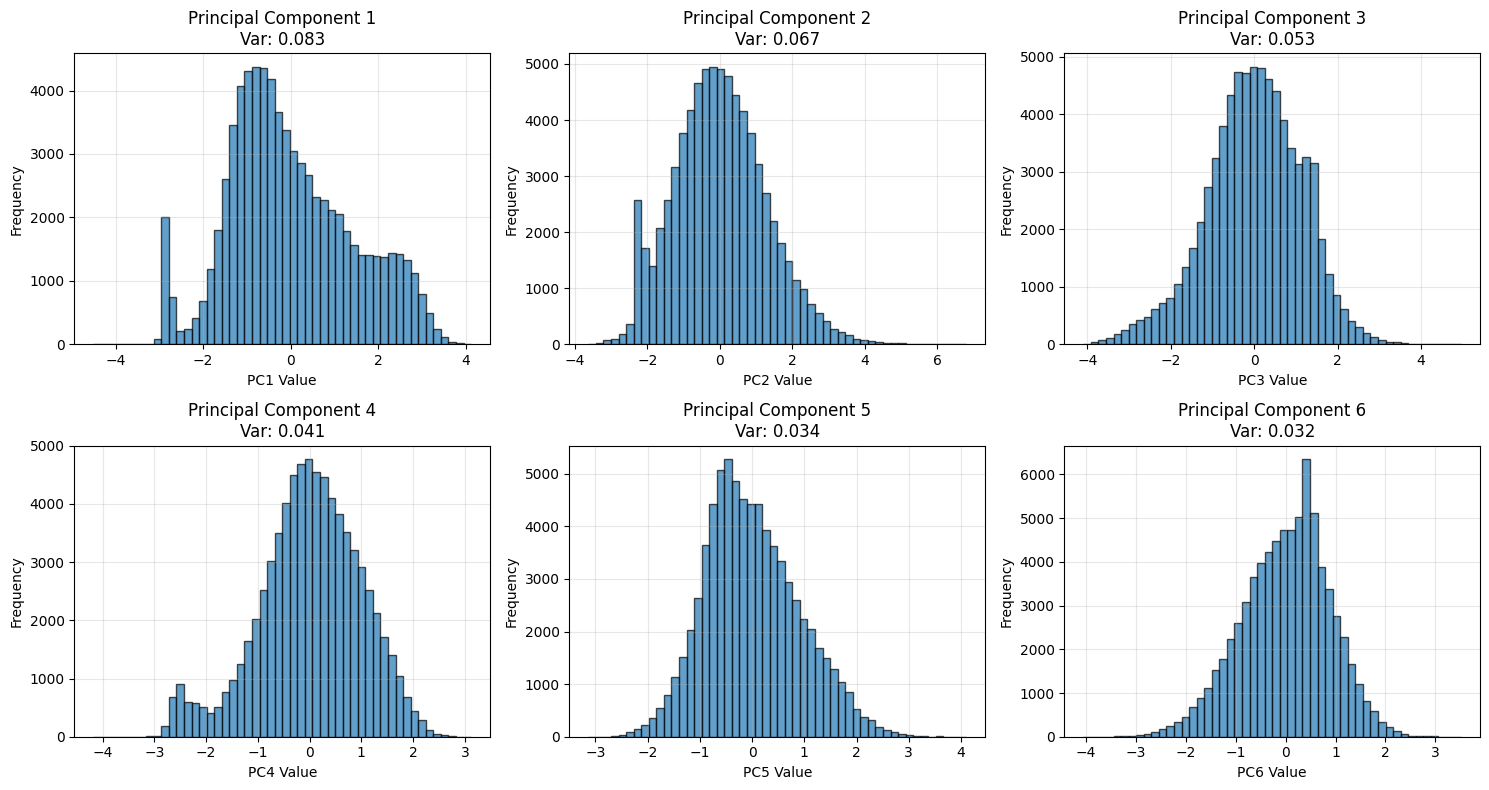


Image feature distributions look reasonable!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of first few PCA components
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].hist(train_image_features_reduced[:, i], bins=50,
                 edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(f'PC{i+1} Value')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Principal Component {i+1}\n'
                     f'Var: {pca.explained_variance_ratio_[i]:.3f}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nImage feature distributions look reasonable!")

## Summary

Image feature extraction complete!

In [ ]:
print("IMAGE FEATURE EXTRACTION SUMMARY")
print("=" * 60)
print(f"\n1. Model Used: ResNet50 (MIT-compatible license)")
print(f"   - Pretrained on ImageNet")
print(f"   - ~25M parameters")
print(f"   - Feature dimension: 2048 → {n_components} (PCA)")

print(f"\n2. Training Set:")
print(f"   - Total samples: {len(train_df):,}")
print(f"   - Features extracted: {train_image_features_reduced.shape}")

print(f"\n3. Test Set:")
print(f"   - Total samples: {len(test_df):,}")
print(f"   - Features extracted: {test_image_features_reduced.shape}")

print(f"\n4. Feature Quality:")
print(f"   - PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")
print(f"   - Non-zero features: {(train_image_features_reduced != 0).any(axis=1).sum():,}")

print(f"\n5. Saved Files:")
for file in sorted(Path(FEATURES_DIR).glob('image_*')):
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"   - {file.name} ({size_mb:.1f} MB)")

print("\n" + "=" * 60)
print("\nImage feature extraction complete!")

IMAGE FEATURE EXTRACTION SUMMARY

1. Model Used: ResNet50 (MIT-compatible license)
   - Pretrained on ImageNet
   - ~25M parameters
   - Feature dimension: 2048 → 128 (PCA)

2. Training Set:
   - Total samples: 75,000
   - Features extracted: (75000, 128)

3. Test Set:
   - Total samples: 75,000
   - Features extracted: (75000, 128)

4. Feature Quality:
   - PCA explained variance: 90.4%
   - Non-zero features: 75,000

5. Saved Files:
   - image_features_test.npy (36.6 MB)
   - image_features_test_full.npy (146.5 MB)
   - image_features_train.npy (36.6 MB)
   - image_features_train_full.npy (146.5 MB)
   - image_pca.pkl (0.3 MB)


Image feature extraction complete!
